# Results

## Setup

In [1]:
import os

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import xarray as xr
import rioxarray as rxr

In [5]:
import rasterio

In [6]:
import matplotlib.cm as cm
import matplotlib.colors as colors

In [7]:
from scipy.stats import spearmanr

In [8]:
DATA_DIR = '../data'

In [9]:
FIGURES_DIR = '../saved_figures'

In [10]:
def tileId_to_epsg(tileId):
    zone = int(tileId[:2])
    return f'EPSG:326{zone}'

In [11]:
data_tiles_all = {}
data_tiles_dir = os.path.join(DATA_DIR, 'data_tiles')
for f in os.listdir(data_tiles_dir):
    if not f.startswith('data_tile'):
        continue

    tile_id = f[10:15]

    f_full = os.path.join(data_tiles_dir, f)

    data_tiles_all[tile_id] = f_full
    
    # data_tiles_all[tile_id] = xr.open_dataset(f_full, chunks={})
    # data_tiles_all[tile_id].chunk({'y': 2048, 'x': 2048})
    # tile_crs = tileId_to_epsg(tile_id)
    # data_tiles_all[tile_id].rio.write_crs(tile_crs, inplace=True)

In [12]:
# pred_dir = os.path.join(DATA_DIR, 'predictions/rf_env_single')
pred_dir = os.path.join(DATA_DIR, 'predictions/rf')

In [13]:
pred_tiles_all = {}
for f in os.listdir(pred_dir):
    if not f.endswith('pred.tif'):
        continue

    tile_id = f[:5]
    f_full = os.path.join(pred_dir, f)
    pred_tiles_all[tile_id] = f_full

## Setup tile

In [41]:
tileId = '29UPR'

In [42]:
ds = xr.open_dataset(data_tiles_all[tileId], chunks={})
ds.chunk({'y': 2048, 'x': 2048})
tile_crs = tileId_to_epsg(tile_id)
ds.rio.write_crs(tile_crs, inplace=True)

<xarray.Dataset> Size: 409MB
Dimensions:      (y: 1658, x: 1991)
Coordinates:
  * y            (y) float64 13kB 5.55e+06 5.55e+06 ... 5.516e+06 5.516e+06
  * x            (x) float64 16kB 6.7e+05 6.7e+05 ... 7.098e+05 7.098e+05
    spatial_ref  int64 8B 0
Data variables: (12/26)
    latitude     (y, x) float64 26MB dask.array<chunksize=(829, 996), meta=np.ndarray>
    longitude    (y, x) float64 26MB dask.array<chunksize=(829, 996), meta=np.ndarray>
    bitmask      (y, x) float32 13MB dask.array<chunksize=(1658, 1991), meta=np.ndarray>
    Rnir         (y, x) float32 13MB dask.array<chunksize=(1658, 1991), meta=np.ndarray>
    Rgli         (y, x) float32 13MB dask.array<chunksize=(1658, 1991), meta=np.ndarray>
    logchl       (y, x) float32 13MB dask.array<chunksize=(1658, 1991), meta=np.ndarray>
    ...           ...
    grid_id      (y, x) int32 13MB dask.array<chunksize=(1658, 1991), meta=np.ndarray>
    WavesKE      (y, x) float32 13MB dask.array<chunksize=(1658, 1991), meta=np.ndarray>
    Substrate    (y, x) float64 26MB dask.array<chunksize=(1658, 1991), meta=np.ndarray>
    PercGravel   (y, x) float32 13MB dask.array<chunksize=(1658, 1991), meta=np.ndarray>
    PercMud      (y, x) float32 13MB dask.array<chunksize=(1658, 1991), meta=np.ndarray>
    PercSand     (y, x) float32 13MB dask.array<chunksize=(1658, 1991), meta=np.ndarray>
Attributes: (12/57)
    sensor:                MSI
    dir_static:            /home/olley/packages/polymer-master/polymer_auxdata
    dir_common:            /home/olley/packages/polymer-master/polymer_auxdat...
    thres_Rcloud:          0.2
    thres_Rcloud_std:      0.04
    force_initialization:  False
    ...                    ...
    processing_duration:   0:03:33.419731
    l1_filename:           ../data/s2_processed/29UPR/subset-29UPR.nc
    start_time:            2020-06-21 11:33:31
    stop_time:             2020-06-21 11:33:31
    l2_filename:           ../data/s2_processed/29UPR/polymer-29UPR.nc
    l2_format:             NETCDF4_CLASSIC

In [43]:
ds['NDTI'] = (ds['Rw665'] - ds['Rw560']) / (ds['Rw665'] + ds['Rw560'])

In [44]:
pred_ds = xr.open_dataset(pred_tiles_all[tileId], chunks={}).squeeze(drop=True)
pred_ds.chunk({'y': 2048, 'x': 2048})
pred_ds.rio.write_crs(tile_crs, inplace=True)

<xarray.Dataset> Size: 13MB
Dimensions:      (x: 1991, y: 1658)
Coordinates:
  * x            (x) float64 16kB 6.7e+05 6.7e+05 ... 7.098e+05 7.098e+05
  * y            (y) float64 13kB 5.55e+06 5.55e+06 ... 5.516e+06 5.516e+06
    spatial_ref  int64 8B 0
Data variables:
    band_data    (y, x) float32 13MB dask.array<chunksize=(1, 1991), meta=np.ndarray>

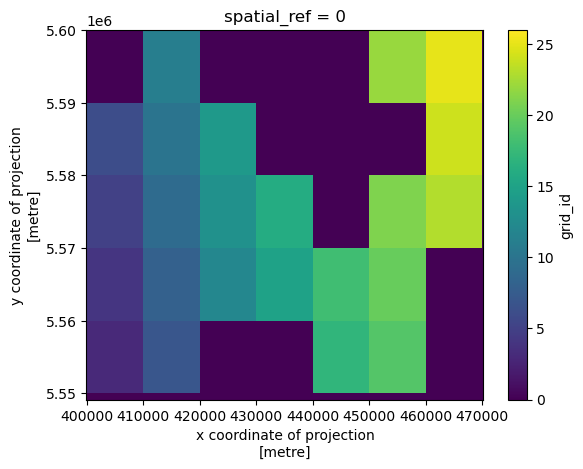

In [18]:
ds['grid_id'].plot()

In [45]:
# 30UVA:
# mask = (ds['grid_id'] == 4)
# for i in range(5, 14):
#     if i in [1, 2, 3, 5, 6, 7, 11]:
#         continue
#     mask |= (ds['grid_id'] == i)

# 30UUA:
# mask = (ds['grid_id'] == 19) | (ds['grid_id'] == 26)

# 29UPR:
mask = (ds['grid_id'] >= 1)


In [46]:
mask_indices = np.where(mask)
y_min, y_max = mask_indices[0].min(), mask_indices[0].max()
x_min, x_max = mask_indices[1].min(), mask_indices[1].max()

In [47]:
pred = pred_ds['band_data'].isel(
    y=slice(y_min, y_max),
    x=slice(x_min, x_max)
).values

ds_slice = ds.isel(
    y=slice(y_min, y_max),
    x=slice(x_min, x_max)
)

In [48]:
pred_mask = np.isnan(pred)

## Overlay predictions on variables

In [49]:
red = ds_slice['Rw665'].values
green = ds_slice['Rw560'].values
blue = ds_slice['Rw443'].values

rgb = np.clip(np.dstack([red, green, blue]), 0, 0.5) * 15
# rgb[pred_mask] = np.nan

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..7.5].


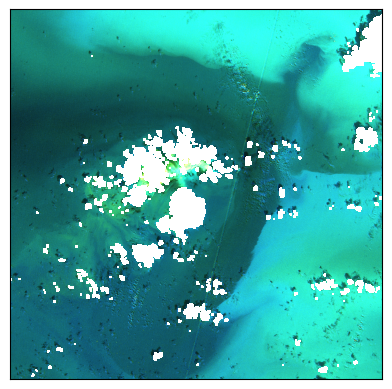

In [50]:
plt.imshow(rgb)
plt.xticks([])
plt.yticks([])
# plt.title('Sentinel-2 (Polymer AC) RGB')
plt.savefig(os.path.join(FIGURES_DIR, 's2_rgb_scilly'))

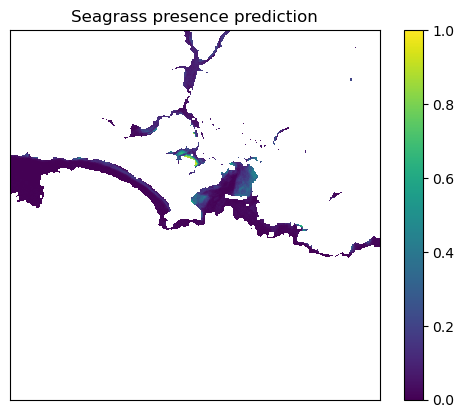

In [56]:
im = plt.imshow(pred)
plt.xticks([])
plt.yticks([])
plt.title('Seagrass presence prediction')
plt.colorbar(im)

In [57]:
pred_cat = pred.copy()
pred_cat[pred < 0.2] = np.nan
# pred_cat[pred >= 0.1] = 1.0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..7.5].


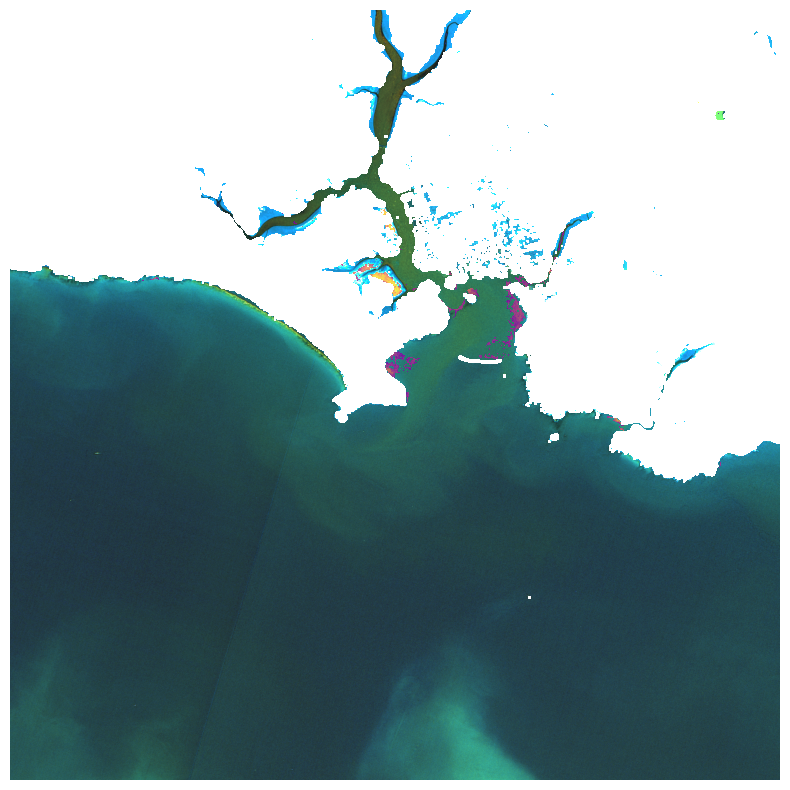

In [58]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rgb, alpha=0.9)
ax.axis('off')
ax.imshow(pred_cat, alpha=0.8, cmap='plasma', vmin=0, vmax=1)
# fig.savefig(os.path.join(FIGURES_DIR, 'pred_overlay_fal'), dpi=300)
plt.show()

In [59]:
predictors = ['Rnir', 'Rw443', 'Rw490', 'Rw560', 'Rw665', 'logchl', 'bathymetry', 'WavesKE', 'PercGravel', 'PercMud', 'PercSand', 'NDTI']

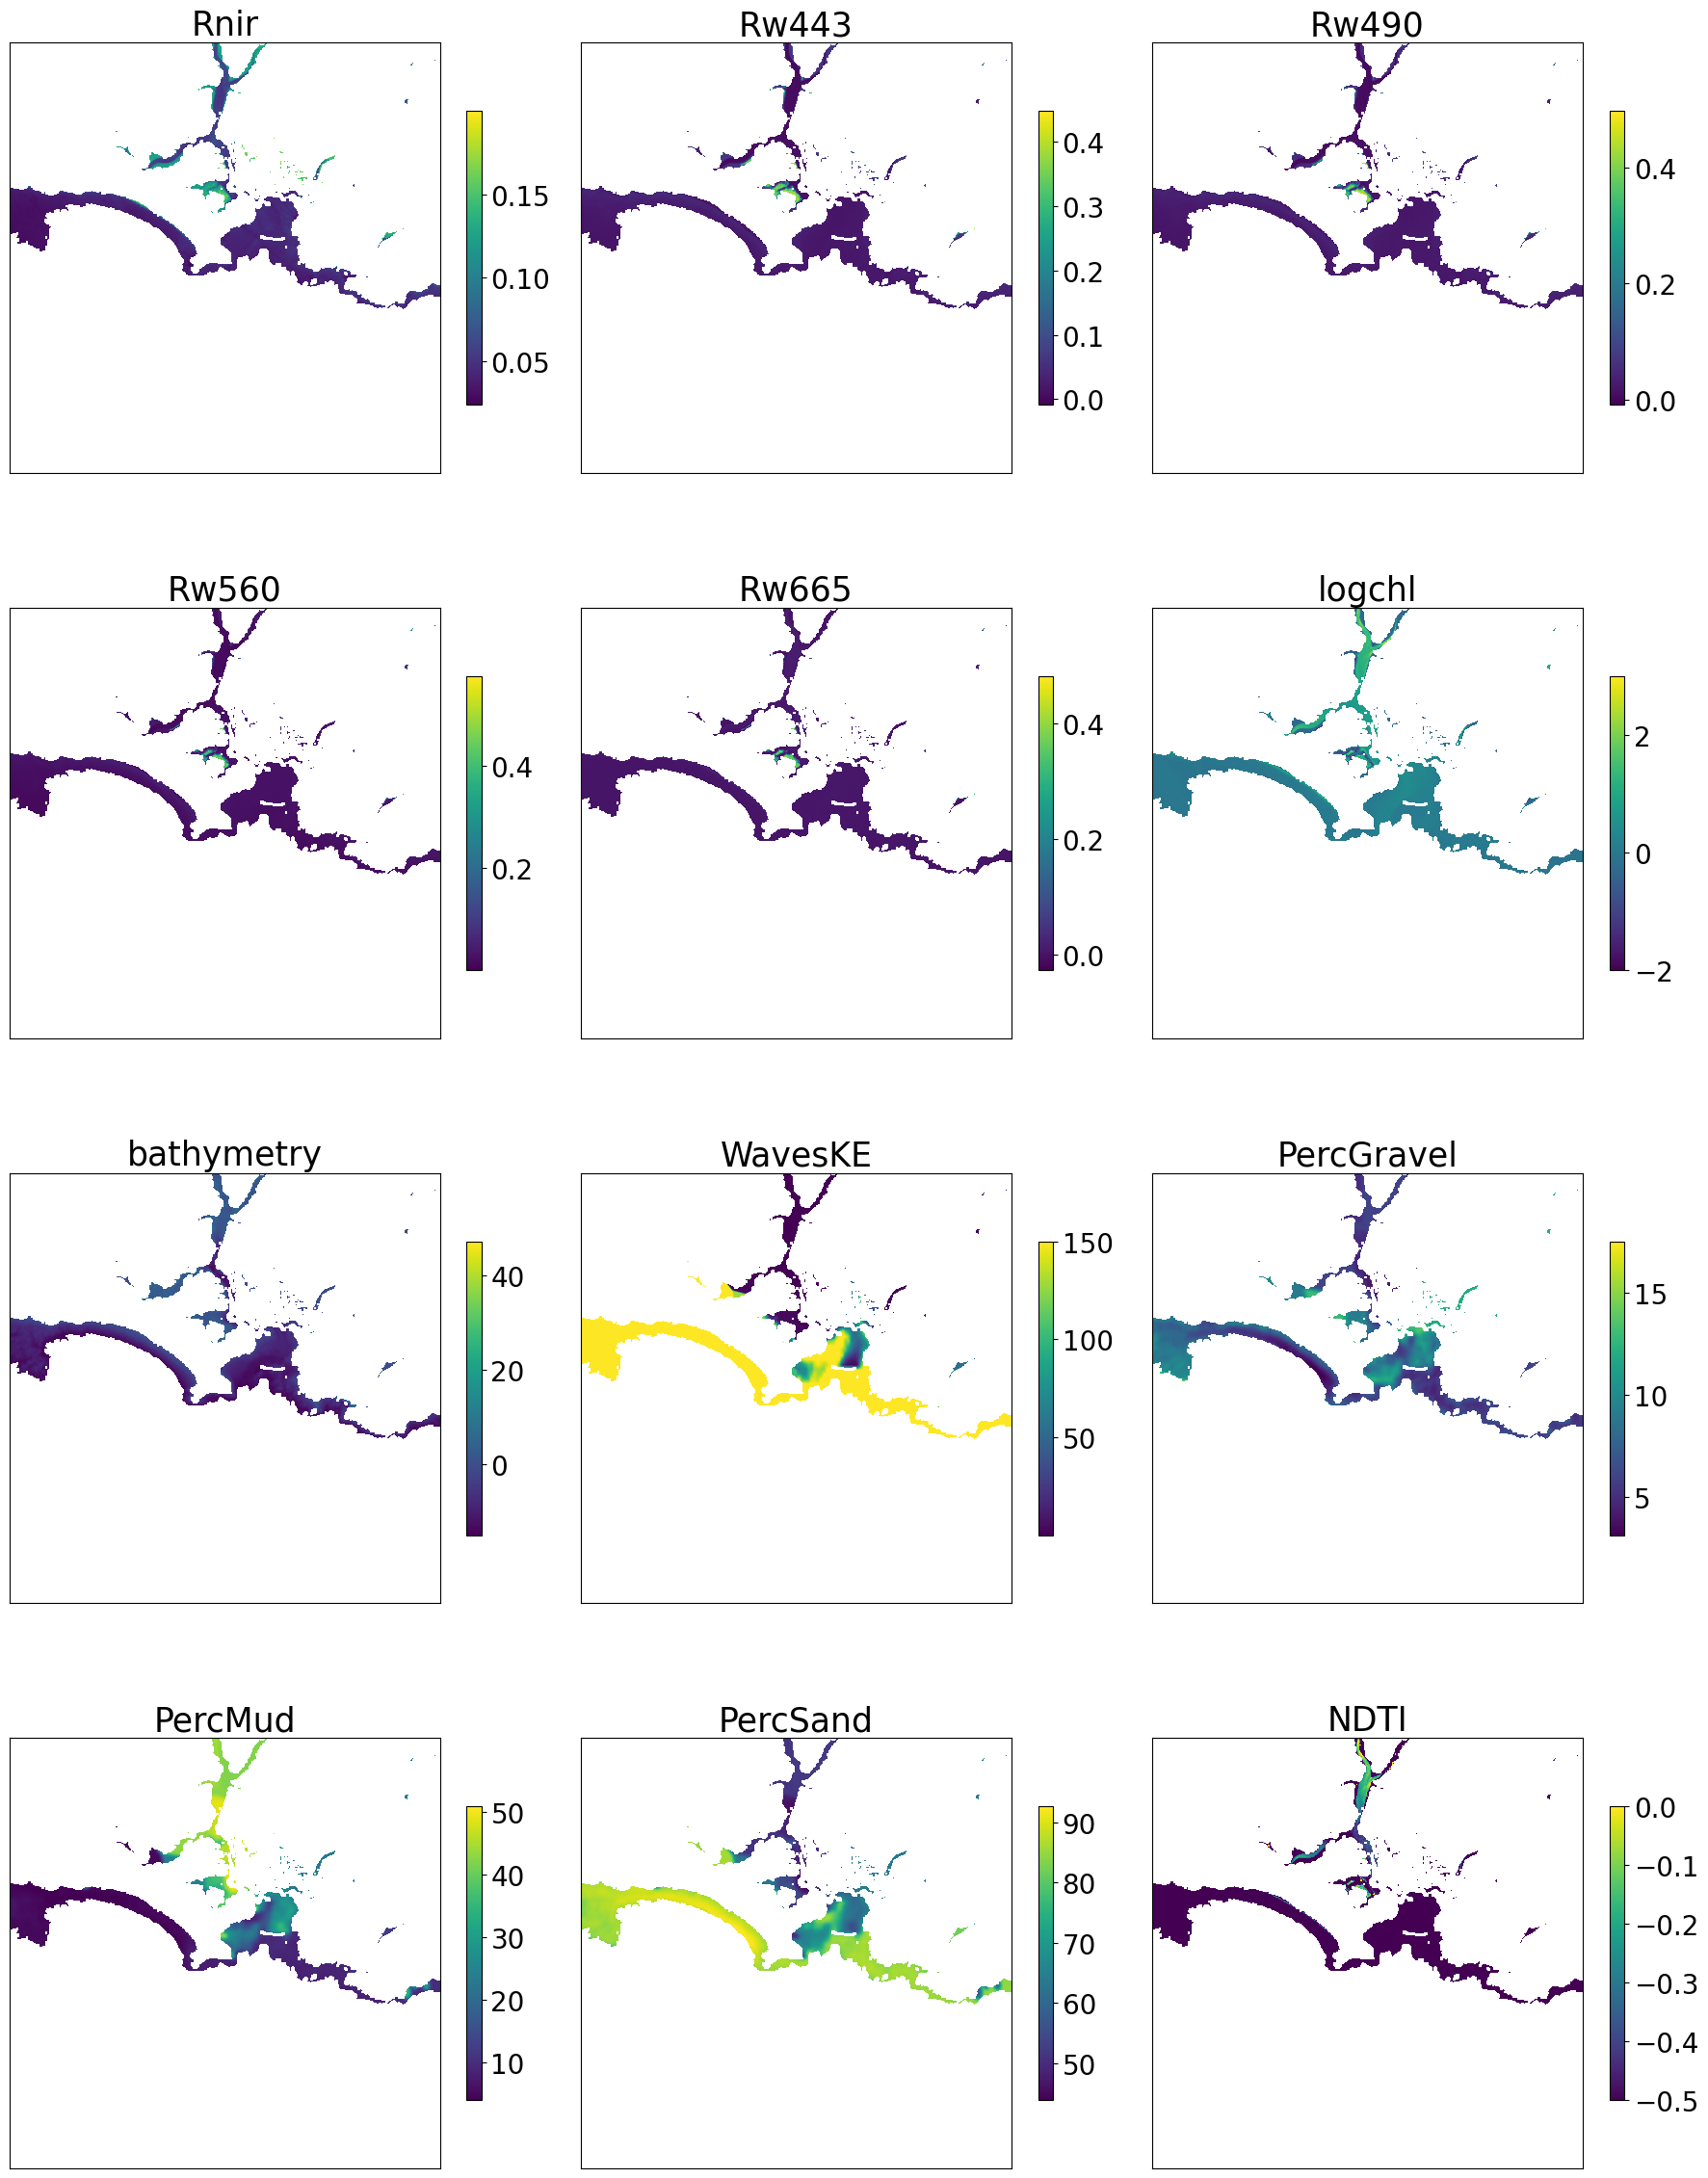

In [62]:
fig, axes = plt.subplots(4, 3, figsize=(18, 24))
for i, p in enumerate(predictors):
    p_vals = ds_slice[p].values
    p_vals[pred_mask] = np.nan
    row = i // 3
    col = i % 3
    if p == 'NDTI':
        vmin = -0.5
        vmax = 0.0
    else:
        vmin = np.nanmin(p_vals)
        vmax = np.nanmax(p_vals)
    im = axes[row, col].imshow(
        p_vals,
        vmin=vmin,
        vmax=vmax
    )
    axes[row, col].set_xticks([])
    axes[row, col].set_yticks([])
    axes[row, col].set_title(p, fontsize=25)
    cbar = plt.colorbar(im, ax=axes[row,col], shrink=0.5)
    cbar.ax.tick_params(labelsize=20)

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'all_vars_plym'), dpi=300)